In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader 
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time
from scipy import stats


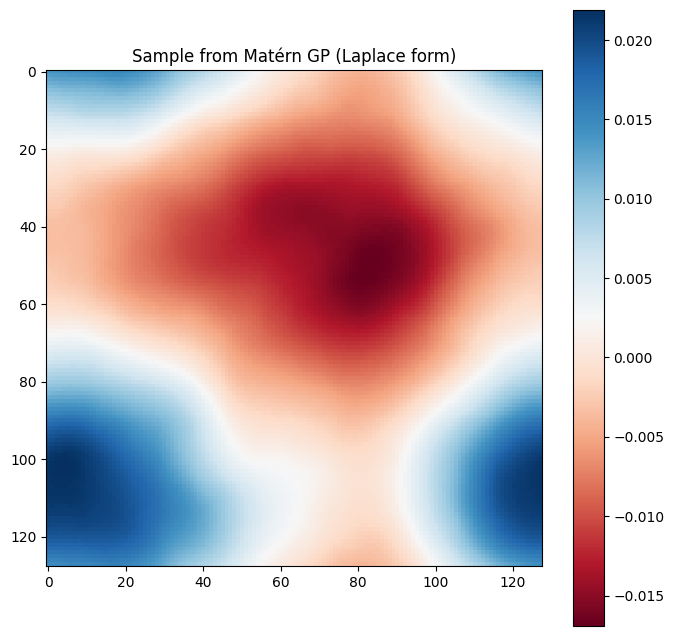

tensor(7.2577e-05)

In [4]:
def generate_matern_laplace(num_samples, grid_size, sigma_sq, length_scale, s, seed=None):
    """
    This function generates samples.
    Generate Matérn GP using the operator form σ²(-Δ + l²I)^{-s} - this is the fourier domain power spectrum of the GRF
    
    Args:
        grid_size (int): Size of the grid (N x N)
        sigma_sq (float): Variance parameter σ²
        length_scale (float): Length scale l
        s (float): Smoothness parameter s
        seed (int): Random seed for reproducibility
    
    Returns:
        torch.Tensor: Sample from the GP
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    # Generate frequency grid (scaled by 2π)
    freq = torch.fft.fftfreq(grid_size, d=1.0) * 2 * math.pi * grid_size
    freq_x, freq_y = torch.meshgrid(freq, freq, indexing='ij')
    
    # Compute -Laplacian in Fourier space: |k|²
    laplacian = freq_x**2 + freq_y**2
    
    # Compute spectral density: σ²(|k|² + l²)^{-s}
    spectral_density = sigma_sq * (laplacian + (1.0 / length_scale**2))**(-s)
    spectral_density[0,0]= 0
    spectral_density = spectral_density.unsqueeze(0)  # Broadcasting
    
    
    # Generate complex Gaussian noise
    noise_real = torch.randn(num_samples, grid_size, grid_size)
    noise_imag = torch.randn(num_samples, grid_size, grid_size)
    noise = noise_real + 1j * noise_imag
    
    # # Apply sqrt of spectral density
    spectral_sample = torch.sqrt(spectral_density) * noise
    
    # # Transform back to spatial domain
    sample = torch.fft.ifft2(spectral_sample, norm='forward')
    sample = sample.real
    
    # eps = torch.randn(num_samples, grid_size, grid_size)
    # E = torch.fft.fft2(eps, norm="ortho")

    # # Filter in Fourier domain
    # X_hat = E * torch.sqrt(spectral_density).unsqueeze(0)

    # # Back to spatial domain
    # x = torch.fft.ifft2(X_hat, norm="ortho").real

    # # Remove per-sample mean (instead of spectral_density[0,0]=0)
    # x = x - x.mean(dim=(1, 2), keepdim=True)



    return sample

def plot_sample(sample):
    """Plot a sample from the GP"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 8))
    plt.imshow(sample.numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title('Sample from Matérn GP (Laplace form)')
    plt.show()

# Example usage

grid_size = 128
sample = generate_matern_laplace(
    num_samples=1000,
    grid_size=grid_size,
    sigma_sq=1,
    length_scale=1.0,
    s=3,
    seed=42
)

# Plot the sample
plot_sample(sample[0,...])
# (sample[:,...]**2).mean()

spatial_variance = (sample**2).mean(dim=(1, 2))
spatial_variance.mean()


In [5]:
def generate_multiscale_matern(
    num_samples: int,
    grid_size: int,
    coarse_params: dict,
    fine_params: dict,
    mix_coarse: float = 1.0,
    mix_fine: float = 0.6,
    seed: int | None = None,
    normalize: bool = True,
):
    """
    Multiscale field = a * (coarse Matérn) + b * (fine Matérn)
    where coarse/fine use different (length_scale, s, sigma_sq).
    """
    seed0 = seed
    seed1 = None if seed is None else seed + 10_000

    x_coarse = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        seed=seed0,
        **coarse_params,
    )
    x_fine = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        seed=seed1,
        **fine_params,
    )

    x = mix_coarse * x_coarse + mix_fine * x_fine

    if normalize:
        # global normalization across all pixels/samples (helpful for training later)
        mean = x.mean()
        std = x.std().clamp_min(1e-8)
        x = (x - mean) / std

    return x


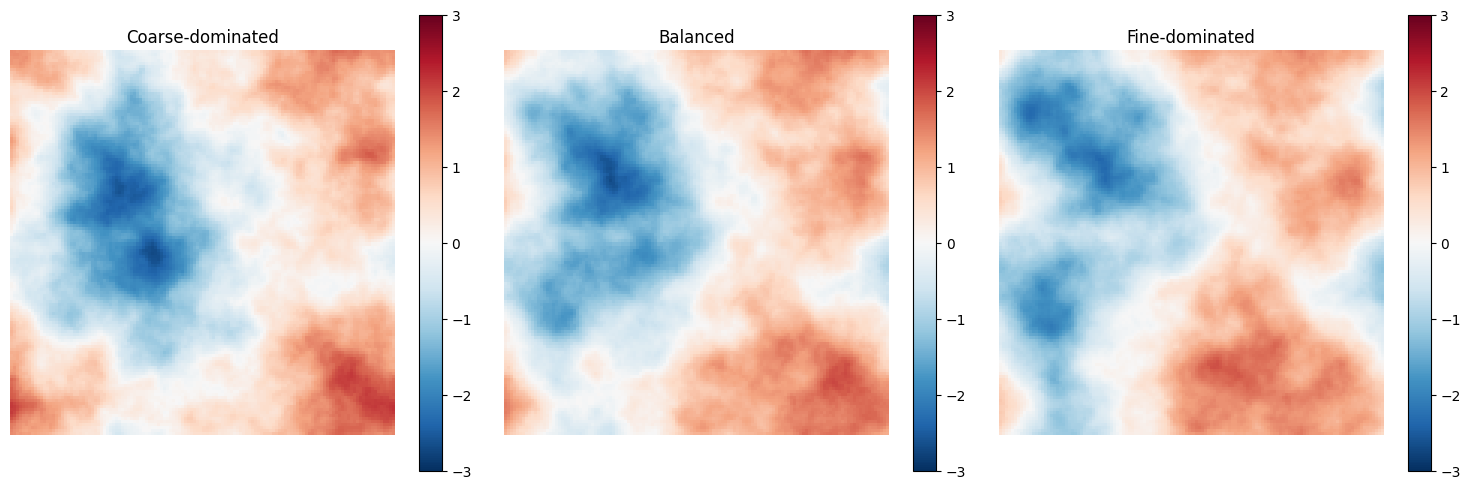

In [6]:
import matplotlib.pyplot as plt

# Generate different configurations
configs = [
    {
        'name': 'Coarse-dominated',
        'coarse': {'length_scale': 12.0, 's': 2.0, 'sigma_sq': 1.0},
        'fine': {'length_scale': 2.0, 's': 2.0, 'sigma_sq': 1.0},
        'mix_coarse': 1.0,
        'mix_fine': 0.3,
    },
    {
        'name': 'Balanced',
        'coarse': {'length_scale': 12.0, 's': 2.0, 'sigma_sq': 1.0},
        'fine': {'length_scale': 2.0, 's': 2.0, 'sigma_sq': 1.0},
        'mix_coarse': 1.0,
        'mix_fine': 1.0,
    },
    {
        'name': 'Fine-dominated',
        'coarse': {'length_scale': 12.0, 's': 2.0, 'sigma_sq': 1.0},
        'fine': {'length_scale': 2.0, 's': 2.0, 'sigma_sq': 1.0},
        'mix_coarse': 0.3,
        'mix_fine': 1.0,
    },
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, config in zip(axes, configs):
    data = generate_multiscale_matern(
        num_samples=1,
        grid_size=128,
        coarse_params=config['coarse'],
        fine_params=config['fine'],
        mix_coarse=config['mix_coarse'],
        mix_fine=config['mix_fine'],
        seed=42,
        normalize=True,
    )
    
    im = ax.imshow(data[0], cmap='RdBu_r', vmin=-3, vmax=3)
    ax.set_title(config['name'])
    ax.axis('off')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('results/figures/two_scale_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
def generate_balanced_mixture(num_samples, grid_size, coarse_params, fine_params, seed=None):
    """Generate balanced dataset by mixing in Fourier space"""
    if seed is not None:
        torch.manual_seed(seed)
    
    # Generate frequency grid
    freq = torch.fft.fftfreq(grid_size) * 2 * math.pi * grid_size
    freq_x, freq_y = torch.meshgrid(freq, freq, indexing='ij')
    k_squared = freq_x**2 + freq_y**2
    
    # Compute both spectral densities
    l_coarse = coarse_params['length_scale']
    l_fine = fine_params['length_scale']
    s = coarse_params['s']
    sigma_sq = coarse_params['sigma_sq']
    
    spec_coarse = sigma_sq * (k_squared / (l_coarse**2) + 1.0)**(-s)
    spec_fine = sigma_sq * (k_squared / (l_fine**2) + 1.0)**(-s)
    
    # Mix spectral densities (this preserves multiscale structure)
    spectral_density = 0.5 * spec_coarse + 0.5 * spec_fine
    spectral_density[0, 0] = 0
    spectral_density = spectral_density.unsqueeze(0)
    
    # Generate noise and transform
    noise_real = torch.randn(num_samples, grid_size, grid_size)
    noise_imag = torch.randn(num_samples, grid_size, grid_size)
    noise = noise_real + 1j * noise_imag
    
    spectral_sample = torch.sqrt(spectral_density) * noise
    sample = torch.fft.ifft2(spectral_sample, norm='forward').real
    
    # Normalize
    sample = (sample - sample.mean()) / sample.std()
    
    return sample

In [8]:
def generate_datasets(num_samples=1000, grid_size=128, seed=42):
    """Generate coarse, fine, and balanced multiscale datasets"""
    
    # More extreme parameter differences
    coarse_params = {
        'sigma_sq': 1.0,
        'length_scale': 30.0,  
        's': 2.5
    }
    
    fine_params = {
        'sigma_sq': 1.0,
        'length_scale': 3.0,   
        's': 2.5        
    }
    
    # More extreme mixing ratios
    x_coarse = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        **coarse_params,
        seed=seed
    )
    # Normalize
    x_coarse = (x_coarse - x_coarse.mean()) / x_coarse.std()
    
    x_fine = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        **fine_params,
        seed=seed + 1000
    )
    # Normalize
    x_fine = (x_fine - x_fine.mean()) / x_fine.std()
    
    # Balanced stays the same
    x_balanced = generate_balanced_mixture(
        num_samples=num_samples,
        grid_size=grid_size,
        coarse_params=coarse_params,
        fine_params=fine_params,
        seed=seed + 2000
    )
    
    return x_coarse, x_fine, x_balanced, coarse_params, fine_params

In [9]:
def get_Fourier_spectrum(data):
    """Calculate radially-averaged power spectrum"""
    data_hat = torch.fft.fftn(data, dim=(1,2), norm="forward")
    fourier_amplitudes = np.abs(data_hat)**2
    fourier_amplitudes = fourier_amplitudes.mean(dim=0)
    npix = data_hat.shape[-1]
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins_w, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                     statistic="mean",
                                     bins=kbins)
    Abins_w *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return kvals, Abins_w

In [10]:
def plot_comparison(x_coarse, x_fine, x_balanced, coarse_params, fine_params):
    """Create comprehensive comparison plots"""
    
    # Compute power spectra
    k_coarse, P_coarse = get_Fourier_spectrum(x_coarse)
    k_fine, P_fine = get_Fourier_spectrum(x_fine)
    k_balanced, P_balanced = get_Fourier_spectrum(x_balanced)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 10))
    
    # Top row: Sample images
    ax1 = plt.subplot(2, 3, 1)
    im1 = ax1.imshow(x_coarse[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax1.set_title('Coarse-dominated\n', fontsize=12)
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046)
    
    ax2 = plt.subplot(2, 3, 2)
    im2 = ax2.imshow(x_fine[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax2.set_title('Fine-dominated\n', fontsize=12)
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046)
    
    ax3 = plt.subplot(2, 3, 3)
    im3 = ax3.imshow(x_balanced[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax3.set_title('Balanced\n', fontsize=12)
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046)
    
    # Bottom left: Linear power spectrum comparison
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(k_coarse, P_coarse, 'b-', linewidth=2, label='Coarse-dominated', alpha=0.8)
    ax4.plot(k_fine, P_fine, 'r-', linewidth=2, label='Fine-dominated', alpha=0.8)
    ax4.plot(k_balanced, P_balanced, 'g-', linewidth=2, label='Balanced', alpha=0.8)
    ax4.set_xlabel('Wavenumber k', fontsize=11)
    ax4.set_ylabel('Power P(k)', fontsize=11)
    ax4.set_title('Power Spectrum (Linear Scale)', fontsize=12)
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    # Bottom middle: Log-log power spectrum
    ax5 = plt.subplot(2, 3, 5)
    ax5.loglog(k_coarse[1:], P_coarse[1:], 'b-', linewidth=2, label='Coarse-dominated', alpha=0.8)
    ax5.loglog(k_fine[1:], P_fine[1:], 'r-', linewidth=2, label='Fine-dominated', alpha=0.8)
    ax5.loglog(k_balanced[1:], P_balanced[1:], 'g-', linewidth=2, label='Balanced', alpha=0.8)
    ax5.set_xlabel('Wavenumber k', fontsize=11)
    ax5.set_ylabel('Power P(k)', fontsize=11)
    ax5.set_title('Power Spectrum (Log-Log Scale)', fontsize=12)
    ax5.legend(fontsize=10)
    ax5.grid(True, alpha=0.3, which='both')
    
    # Bottom right: Ratio plots
    ax6 = plt.subplot(2, 3, 6)
    ratio_coarse_balanced = P_coarse / (P_balanced + 1e-10)
    ratio_fine_balanced = P_fine / (P_balanced + 1e-10)
    ax6.semilogx(k_coarse[1:], ratio_coarse_balanced[1:], 'b-', linewidth=2, 
                 label='Coarse/Balanced', alpha=0.8)
    ax6.semilogx(k_fine[1:], ratio_fine_balanced[1:], 'r-', linewidth=2, 
                 label='Fine/Balanced', alpha=0.8)
    ax6.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    ax6.set_xlabel('Wavenumber k', fontsize=11)
    ax6.set_ylabel('Power Ratio', fontsize=11)
    ax6.set_title('Power Ratios (vs Balanced)', fontsize=12)
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/figures/two_scale_dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("\n=== Dataset Statistics ===")
    print(f"\nCoarse-dominated:")
    print(f"  Mean: {x_coarse.mean():.4f}, Std: {x_coarse.std():.4f}")
    print(f"  Total power: {P_coarse.sum():.4f}")
    
    print(f"\nFine-dominated:")
    print(f"  Mean: {x_fine.mean():.4f}, Std: {x_fine.std():.4f}")
    print(f"  Total power: {P_fine.sum():.4f}")
    
    print(f"\nBalanced:")
    print(f"  Mean: {x_balanced.mean():.4f}, Std: {x_balanced.std():.4f}")
    print(f"  Total power: {P_balanced.sum():.4f}")
    
    # Power in different frequency ranges
    low_k_mask = k_coarse < 10
    high_k_mask = k_coarse > 20
    
    print(f"\n=== Power Distribution ===")
    print(f"Low frequency (k<10) power fraction:")
    print(f"  Coarse: {P_coarse[low_k_mask].sum() / P_coarse.sum():.3f}")
    print(f"  Fine: {P_fine[low_k_mask].sum() / P_fine.sum():.3f}")
    print(f"  Balanced: {P_balanced[low_k_mask].sum() / P_balanced.sum():.3f}")
    
    print(f"\nHigh frequency (k>20) power fraction:")
    print(f"  Coarse: {P_coarse[high_k_mask].sum() / P_coarse.sum():.3f}")
    print(f"  Fine: {P_fine[high_k_mask].sum() / P_fine.sum():.3f}")
    print(f"  Balanced: {P_balanced[high_k_mask].sum() / P_balanced.sum():.3f}")

Generating multiscale datasets...
Creating comparison plots...


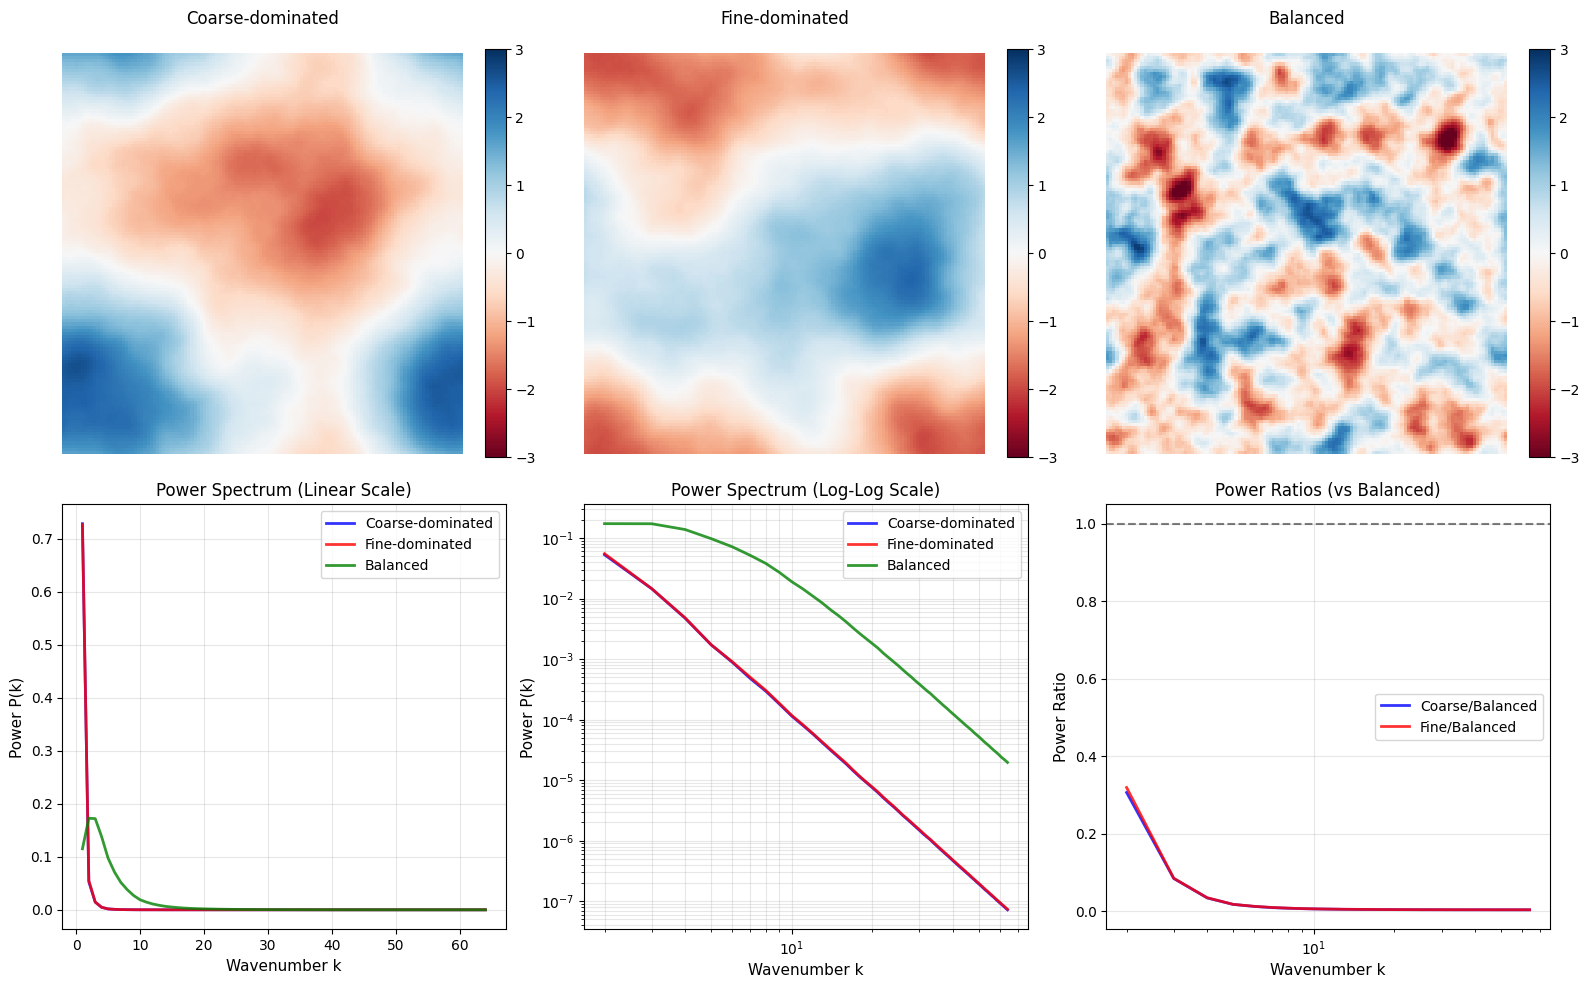


=== Dataset Statistics ===

Coarse-dominated:
  Mean: 0.0000, Std: 1.0000
  Total power: 0.8045

Fine-dominated:
  Mean: -0.0000, Std: 1.0000
  Total power: 0.8051

Balanced:
  Mean: 0.0000, Std: 1.0000
  Total power: 0.9737

=== Power Distribution ===
Low frequency (k<10) power fraction:
  Coarse: 0.999
  Fine: 0.999
  Balanced: 0.908

High frequency (k>20) power fraction:
  Coarse: 0.000
  Fine: 0.000
  Balanced: 0.012

Done! Check 'results/figures/two_scale_dataset_comparison.png' for results.


In [11]:
print("Generating multiscale datasets...")
x_coarse, x_fine, x_balanced, coarse_params, fine_params = generate_datasets(
    num_samples=1000,
    grid_size=128,
    seed=42
)

print("Creating comparison plots...")
plot_comparison(x_coarse, x_fine, x_balanced, coarse_params, fine_params)

print("\nDone! Check 'results/figures/two_scale_dataset_comparison.png' for results.")

tensor([   0.0000,    6.2832,   12.5664,   18.8496,   25.1327,   31.4159,
          37.6991,   43.9823,   50.2655,   56.5487,   62.8319,   69.1150,
          75.3982,   81.6814,   87.9646,   94.2478,  100.5310,  106.8142,
         113.0973,  119.3805,  125.6637,  131.9469,  138.2301,  144.5133,
         150.7964,  157.0796,  163.3628,  169.6460,  175.9292,  182.2124,
         188.4956,  194.7787,  201.0619,  207.3451,  213.6283,  219.9115,
         226.1947,  232.4779,  238.7610,  245.0442,  251.3274,  257.6106,
         263.8938,  270.1770,  276.4602,  282.7433,  289.0265,  295.3097,
         301.5929,  307.8761,  314.1593,  320.4425,  326.7256,  333.0088,
         339.2920,  345.5752,  351.8584,  358.1416,  364.4247,  370.7079,
         376.9911,  383.2743,  389.5575,  395.8407, -402.1239, -395.8407,
        -389.5575, -383.2743, -376.9911, -370.7079, -364.4247, -358.1416,
        -351.8584, -345.5752, -339.2920, -333.0088, -326.7256, -320.4425,
        -314.1593, -307.8761, -301.592

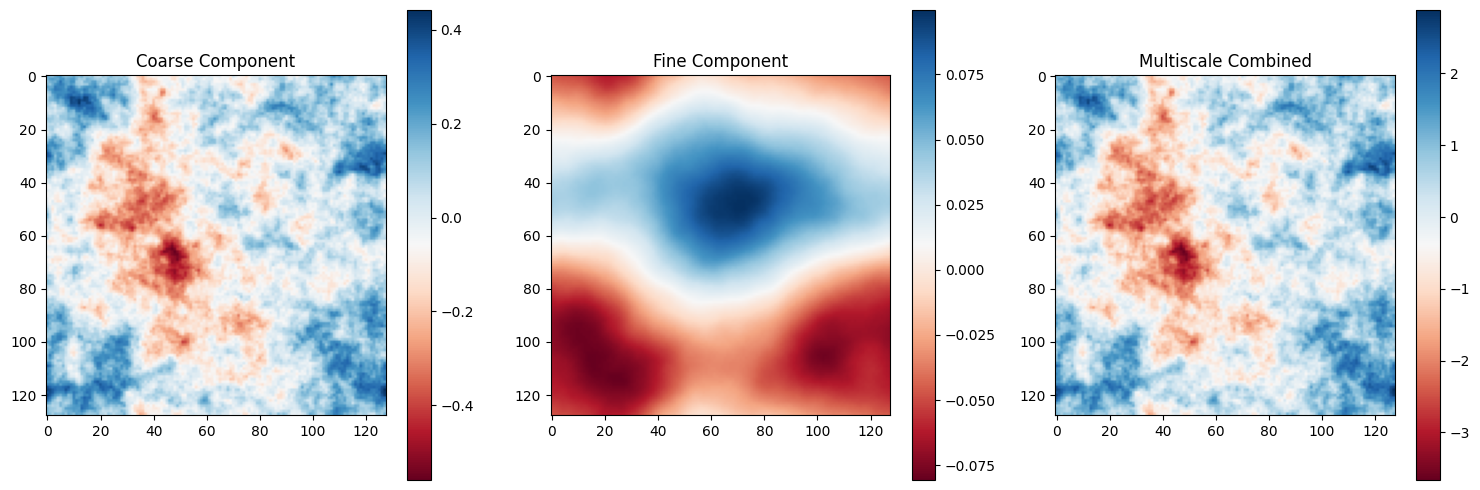

In [82]:
import matplotlib.pyplot as plt

def plot_multiscale_components(coarse, fine, combined, idx=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Coarse component
    im1 = axes[0].imshow(coarse[idx].numpy(), cmap='RdBu')
    axes[0].set_title('Coarse Component')
    plt.colorbar(im1, ax=axes[0])
    
    # Fine component
    im2 = axes[1].imshow(fine[idx].numpy(), cmap='RdBu')
    axes[1].set_title('Fine Component')
    plt.colorbar(im2, ax=axes[1])
    
    # Combined
    im3 = axes[2].imshow(combined[idx].numpy(), cmap='RdBu')
    axes[2].set_title('Multiscale Combined')
    plt.colorbar(im3, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

# Test generation
coarse_params = {'sigma_sq': 1.0, 'length_scale': 3.0, 's': 1.5}
fine_params = {'sigma_sq': 1.0, 'length_scale': 0.5, 's': 2.5}

# Generate separately for visualization
x_coarse = generate_matern_laplace(1, 128, seed=42, **coarse_params)
x_fine = generate_matern_laplace(1, 128, seed=43, **fine_params)
x_combined = generate_multiscale_matern(1, 128, coarse_params, fine_params, seed=42)

plot_multiscale_components(x_coarse, x_fine, x_combined)